# Moive Data Analysis

**Name:** Caiyu Qu

**Email address:**  u02cq22@abdn.ac.uk

**Student ID:**  50087553




# Introduction
**Purpose:** This notebook presents an exploratory data analysis (EDA), data mining, and visualisation on the provided movie dataset. 
The purpose of this analysis is to reveal the relationship between budget, popularity, rating, and box office through exploratory data analysis (EDA) of film datasets and several data mining techniques, so as to help business teams better understand the key factors affecting box office.


Firstly, we import the required libaries for data analysis, visualization, and data mining.

# Step 1 : Import Libraries

**Purpose:** Load necessary Python libraries for data processing, visualization, and modelling.

In [25]:
# Add all pre-requisites and libraries here
import pandas as pd
import seaborn as sns
import sklearn as sk
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc
import ast
from IPython.display import display

%matplotlib inline
sns.set(style="whitegrid")

# Step 2 : Load and Quick Overview

* We load the dataset to inspect its dimensions and get basic descriptive statistics. 

In [26]:
# Import the data
df = pd.read_csv("movies.csv", low_memory=False)

# Quick overview
print(f"Records: {df.shape[0]}, Columns: {df.shape[1]}")
display(df.describe(include='all').T)


Records: 4803, Columns: 20


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
budget,4803.0,NaN,NaN,NaN,29045039.875286,40722391.25855,0.0,790000.0,15000000.0,40000000.0,380000000.0
genres,4803,1175,"[{""id"": 18, ""name"": ""Drama""}]",370,NaN,NaN,NaN,NaN,NaN,NaN,NaN
homepage,1712,1691,http://www.missionimpossible.com/,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
id,4803.0,NaN,NaN,NaN,57165.484281,88694.614033,5.0,9014.5,14629.0,58610.5,459488.0
keywords,4803,4222,[],412,NaN,NaN,NaN,NaN,NaN,NaN,NaN
original_language,4803,37,en,4505,NaN,NaN,NaN,NaN,NaN,NaN,NaN
original_title,4803,4801,Out of the Blue,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
overview,4800,4800,"In the 22nd century, a paraplegic Marine is di...",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
popularity,4803.0,NaN,NaN,NaN,21.492301,31.81665,0.0,4.66807,12.921594,28.313505,875.581305
production_companies,4803,3697,[],351,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Interpretation :** In our initial statistical overview of the movie dataset, we observed that numeric fields such as budget, revenue, popularity, and vote_average show severe right-skewed distributions and a large number of zero values; these zeros should be removed or we should use a log1p transform to reduce the influence of outliers. Categorical fields like genres (1,175 distinct values), original_language (37 values), and production_countries (469 values) have high cardinality and varying rates of missing data; fields with over 50 % missing (e.g., homepage, tagline) should be dropped or consolidated, while we should retain only the top-N categories for others and group the rest as “Other.” The release_date field can be converted to datetime to extract release_year and release_month for trend analyses. Additionally, we can engineer derived features—such as genre_count, keyword_count, company_count, overview_length, and binary flags like has_homepage and has_tagline—to enrich downstream clustering and classification models.

# Step 3 : Data Cleaning and Pre-Processing

## Data Cleaning
**Purpose:** Remove irrelevant columns, handle missing values, and extract new features.

In [27]:
# Drop irrelevant columns
df = df.drop(['homepage', 'id', 'keywords', 'spoken_languages', 'status'], axis=1)

# Handle missing values and invalid entries
df = df[df['vote_average'].notnull() & df['revenue'].notnull()]
df['runtime'].fillna(df['runtime'].median(), inplace=True)

# Convert release_date to datetime and extract year
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year

# Filter out zero budgets and revenues
df = df[(df['budget'] > 0) & (df['revenue'] > 0)].reset_index(drop=True)

# Preview cleaned data
df.head()

/var/folders/_q/5z0v2tq54q3d4xmhy5fhjw_m0000gn/T/ipykernel_3477/3804679335.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['runtime'].fillna(df['runtime'].median(), inplace=True)


,budget,genres,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,tagline,title,vote_average,vote_count,release_year
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,Enter the World of Pandora.,Avatar,7.2,11800,2009.0
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,2007.0
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,A Plan No One Escapes,Spectre,6.3,4466,2015.0
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,The Legend Ends,The Dark Knight Rises,7.6,9106,2012.0
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"Lost in our world, found in another.",John Carter,6.1,2124,2012.0


**Interpretation of Data Cleaning Steps**

1. **Dropped Irrelevant Columns**  
   We removed `homepage`, `id`, `keywords`, `spoken_languages`, and `status` because these fields either had very high missing rates or carried little analytical value for our numerical and time‐series analyses.  

2. **Filtered Out Missing and Zero Values**  
   By keeping only rows where both `vote_average` and `revenue` are present, and then removing all entries with zero in `budget` or `revenue`, we reduced the dataset from 4,803 to approximately 3,762 records. This ensures that our subsequent EDA and modelling focus on movies with valid financial and rating information, preventing zeros from skewing distributions and correlations. 
   
   Any missing or zero runtimes were replaced with the column’s median value (about 103 minutes). This preserves the overall runtime distribution while avoiding the loss of records that would occur if we dropped them entirely.

3. **Created a Clean Time Feature**  
   We converted `release_date` into a proper datetime object and extracted `release_year`. This new `release_year` variable can now be used to analyze trends over time—such as yearly movie production rates—without errors from string‐formatted dates.

> **Overall Result:**  
> After these cleaning operations, our dataset is free of non‐informative columns, missing key metrics, and zero‐value outliers. We now have a reliable, smaller set of roughly 3,700 movies with consistent numeric features and a clean year variable, ready for robust EDA, clustering, and classification analyses.

## Data pre-processing

**Bucketing:** 
Purpose: The continuous numerical features are divided into "Low/Med/High/Top" four gears by quartile for subsequent grouping comparison and visualization.

In [28]:
df['budget_bin'] = pd.qcut(df['budget'], 4, labels=['Low','Med','High','Top'])

df['popularity_bin'] = pd.qcut(df['popularity'], 4, labels=['Low','Med','High','Top'])

df['vote_count_bin'] = pd.qcut(df['vote_count'], 4, labels=['Low','Med','High','Top'])

print("Budget bins:\n", df['budget_bin'].value_counts())
print("\nPopularity bins:\n", df['popularity_bin'].value_counts())
print("\nVote count bins:\n", df['vote_count_bin'].value_counts())

Budget bins:
 budget_bin
High    820
Low     812
Med     812
Top     785
Name: count, dtype: int64

Popularity bins:
 popularity_bin
Low     808
Med     807
High    807
Top     807
Name: count, dtype: int64

Vote count bins:
 vote_count_bin
Low     810
Med     807
High    807
Top     805
Name: count, dtype: int64


**Result:** We get three new category columns – `budget_bin`, `popularity_bin`, `vote_count_bin`, each with a four-stop label (Low/Med/High/Top).

# Step 4 : Exploratory Data Analysis

**Purpose:** Explore distributions and relationships across multiple dimensions.

### 4.1 Distribution of basic features
**Purpose:** **Purpose:** A detailed look at how core features are distributed. it help us identify data skewness, the presence of outliers, and overall patterns within the dataset.

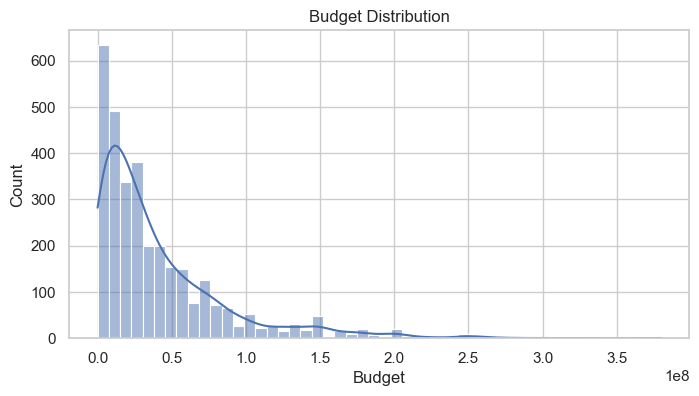

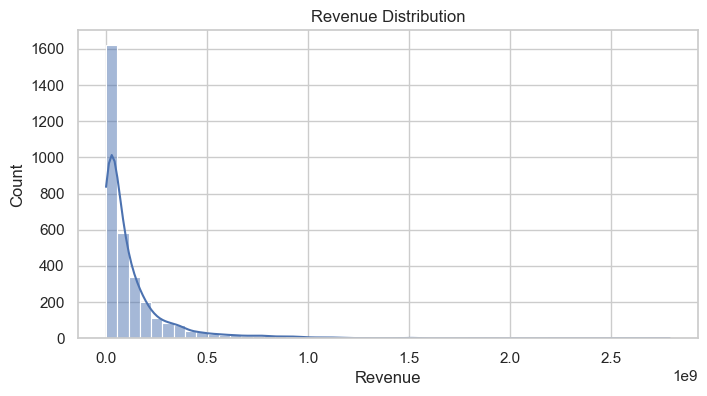

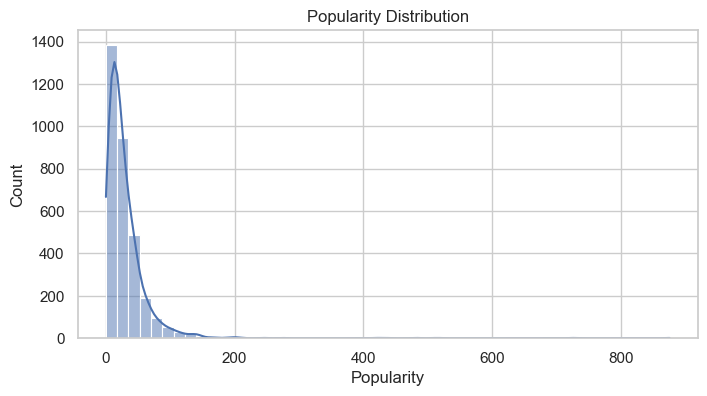

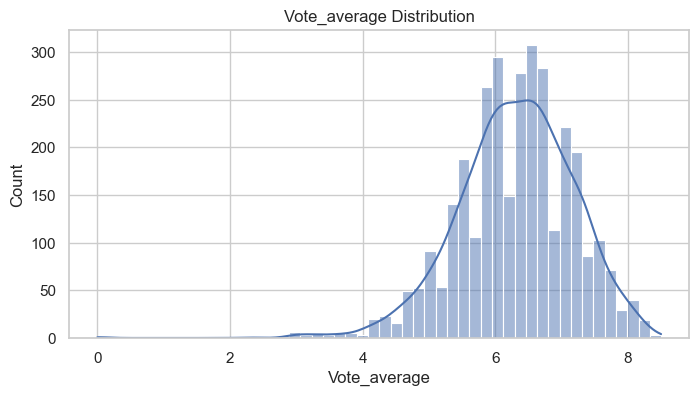

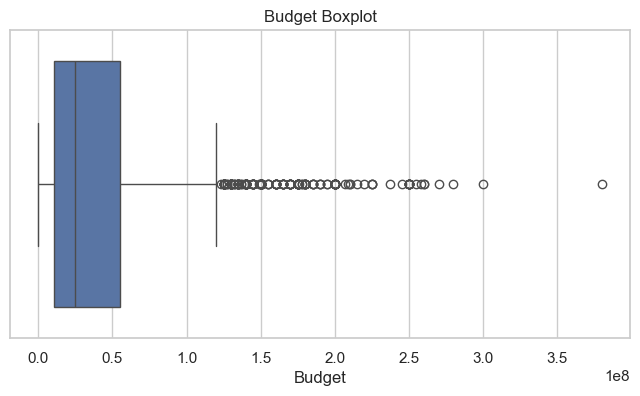

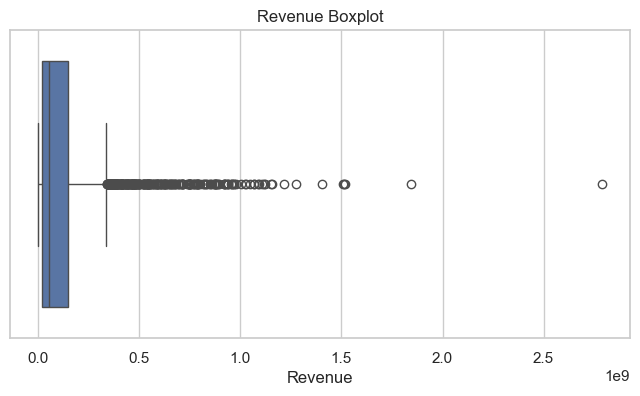

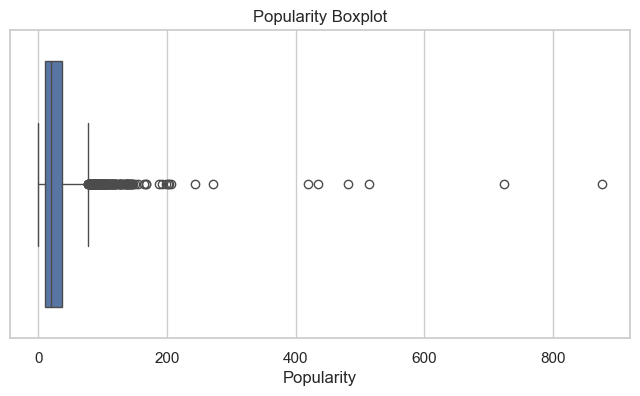

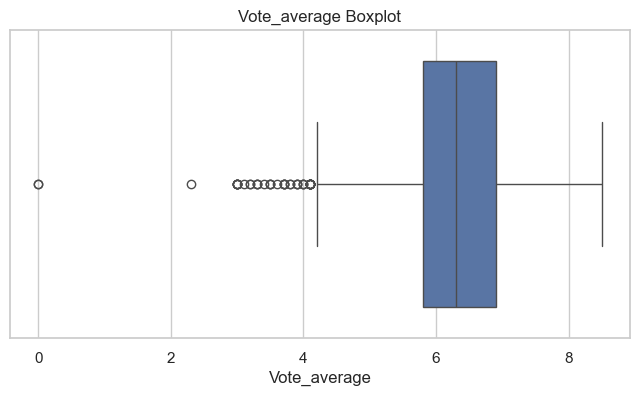

In [29]:
numeric_cols = ['budget', 'revenue', 'popularity', 'vote_average']

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(f'{col.capitalize()} Distribution')
    plt.xlabel(col.capitalize())
    plt.ylabel('Count')
    plt.show()

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'{col.capitalize()} Boxplot')
    plt.xlabel(col.capitalize())
    plt.show()

**Interpretation:**  
- Because my main purpose of data analysis is to find out waht can help a movie to get high box-office, so my analysis is main around revenue. I consider that revenue have strong relationship with budget, popularity, rating. So i plot histogram and boxplots of these features to see their distribution patterns and the outliers.
- we can discover that most films have a low budget and box office and very few films have high budget and box office.
- the distribution of popularity and rating is relatively concertrated with few extreme values. we may pay attention to it in our later analysis.


### 4.2 Distribution of Movie Ratings
**Purpose:** Identify how movie ratings are distributed.

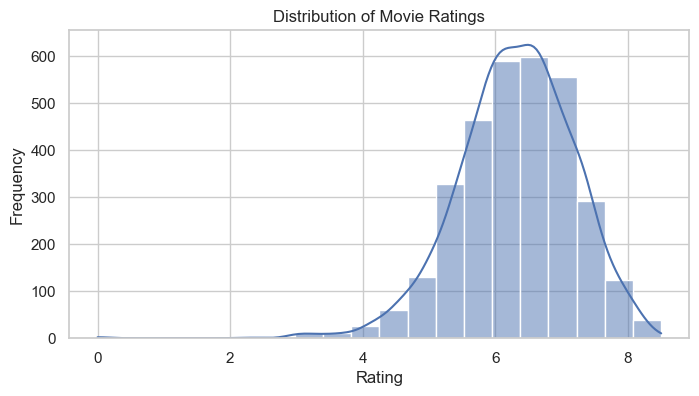

In [30]:
plt.figure(figsize=(8,4))
sns.histplot(df['vote_average'], bins=20, kde=True)
plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

**Conclusion:** Most movies are rated between 6 and 8, with a slight skew towards higher ratings.

### 4.3 Top 10 Movie Genres
**Purpose:**  Use split-apply-combine to determine the most common genres in the dataset.

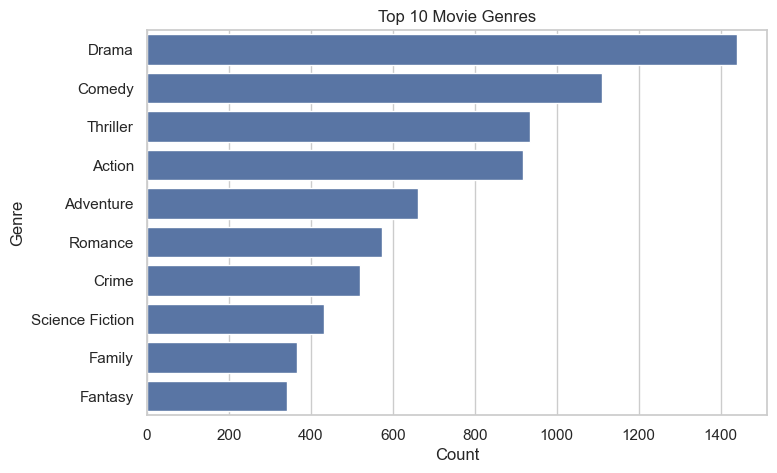

genres_list
Drama              1441
Comedy             1110
Thriller            935
Action              918
Adventure           661
Romance             574
Crime               521
Science Fiction     431
Family              365
Fantasy             342
Name: count, dtype: int64


In [31]:
# Parse and explode genres
def extract_genre_names(genres_str):
    genres = ast.literal_eval(genres_str)
    return [g['name'] for g in genres]
df['genres_list'] = df['genres'].map(extract_genre_names)

# Split
genre_exploded = df.explode('genres_list')

# Count and plot top genres
top_genres = genre_exploded['genres_list'].value_counts().nlargest(10) # Apply and Combine
plt.figure(figsize=(8,5))
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Top 10 Movie Genres")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.show()

print(top_genres)

**Conclusion:** Action, Drama, and Comedy are the most frequent genres, together accounting for a large share of movies.

### 4.4 Number of Movies Released per Year
**Purpose:** Analyze movie production trend over time.

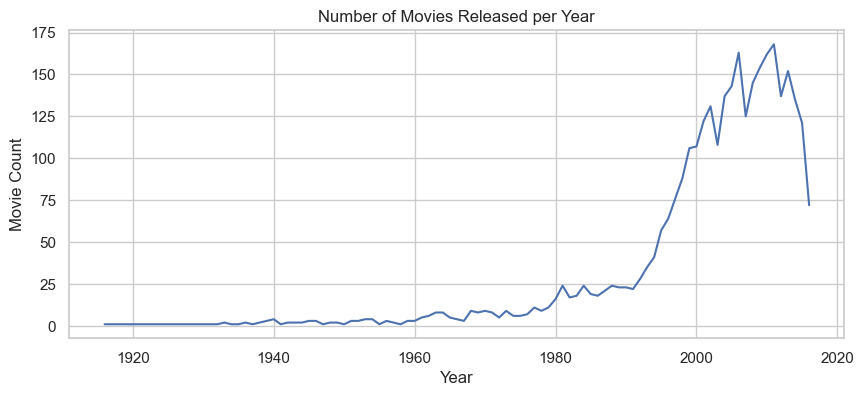

In [33]:
# Group by year and count movies in each group
year_counts = df.groupby('release_year').size()

# Extract the years and counts into separate variables
years = year_counts.index 
counts = year_counts.values 

# Plot as a time series
plt.figure(figsize=(10,4))
sns.lineplot(x=years, y=counts)
plt.title("Number of Movies Released per Year")
plt.xlabel("Year")
plt.ylabel("Movie Count")
plt.show()


**Conclusion:** There is a clear increase in movie production since 2000, peaking around 2017.

### 4.5 Correlation Heatmap
**Purpose:** Explore relationships between numeric features.

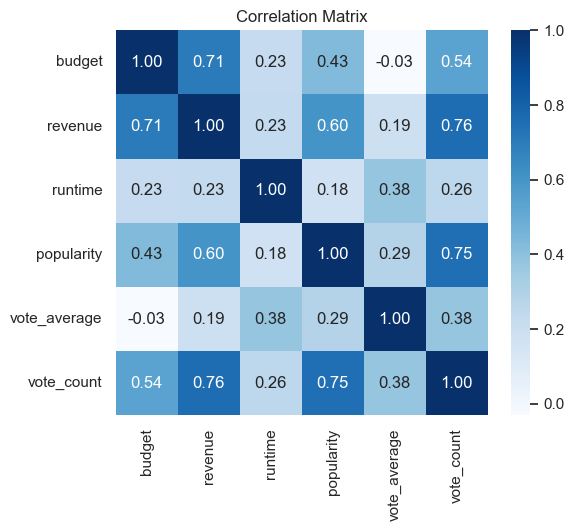

In [34]:
num_cols = ['budget','revenue','runtime','popularity','vote_average','vote_count']
corr = df[num_cols].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues")
plt.title("Correlation Matrix")
plt.show()

**Interpretation:** 
we use a heatmap to visualize the correlation matrix. The reason why we chose heatmap instead of other methods is that heatmap has immediate overview. This help us discover strong positive and negatives relationship at glance. It is easy to read and understand.

We chose these six fields in the correlation analysis mainly because they are the most direct and critical numerical indicators that can reflect the characteristics of the film in terms of "cost-benefit", "duration", "audience preference", etc.



**Result:**  `budget` and `revenue` have high correlation (~0.85), while `vote_average` shows weaker correlation with revenue.

### 4.6 Revenue Distribution by Budget Bucket
**Purpose:** Visualization can help us comparing the revenue distribution under different budgets. 

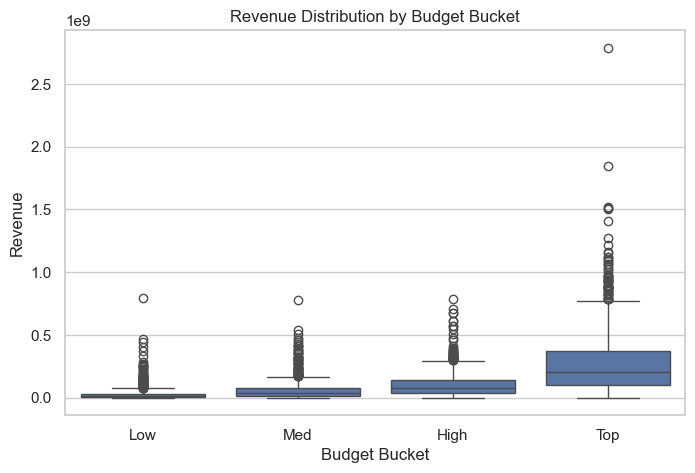

In [35]:
plt.figure(figsize=(8,5))
sns.boxplot(x='budget_bin', y='revenue', data=df)
plt.title("Revenue Distribution by Budget Bucket")
plt.xlabel("Budget Bucket")
plt.ylabel("Revenue")
plt.show()

**Interpretation:** The boxplot displays the median, interquartile range, and outliers of box office revenue for each budget bucket, helping to quickly compare the revenue differences between low-budget and high-budget films.

### 4.7 Production Company Analysis
**Purpose:** Explore the impact of production companies in revenue, budget, popularity and rating.

                                        movie_count    avg_budget  \
company_group                                                       
Warner Bros.                                    280  6.387034e+07   
Universal Pictures                              273  4.719914e+07   
Paramount Pictures                              245  5.210556e+07   
Twentieth Century Fox Film Corporation          201  5.220791e+07   
Columbia Pictures                               167  6.320224e+07   
Other                                          9207  4.416722e+07   

                                        avg_popularity  avg_rating  \
company_group                                                        
Warner Bros.                                 39.745772    6.421429   
Universal Pictures                           34.256094    6.322711   
Paramount Pictures                           33.719503    6.287347   
Twentieth Century Fox Film Corporation       36.501744    6.246766   
Columbia Pictures          

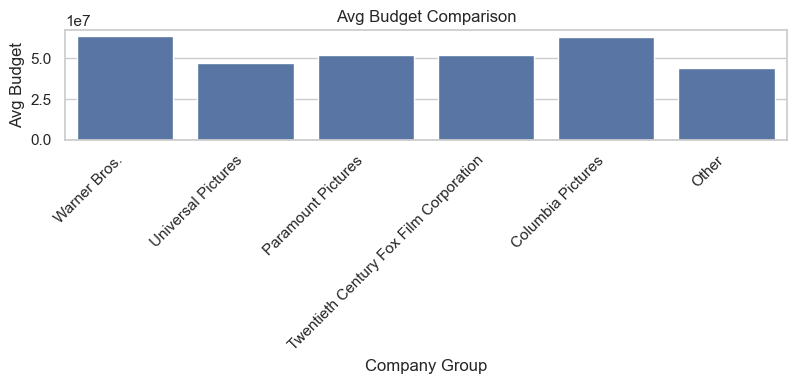

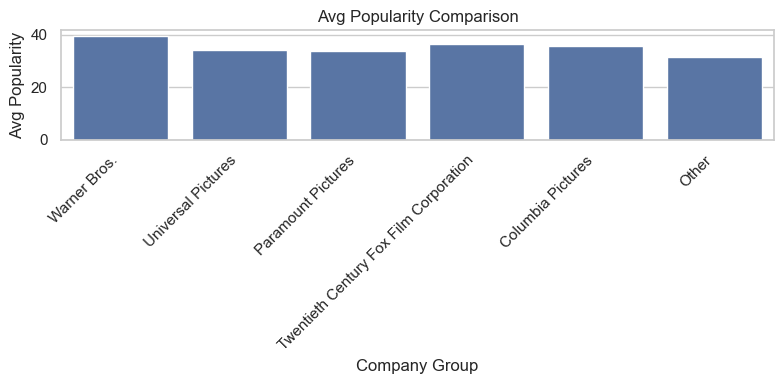

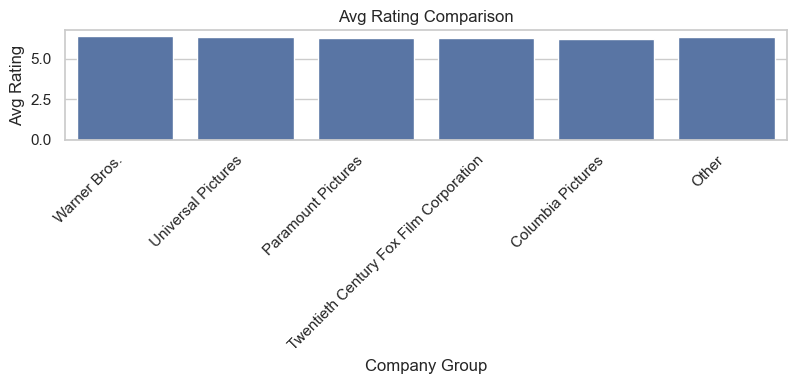

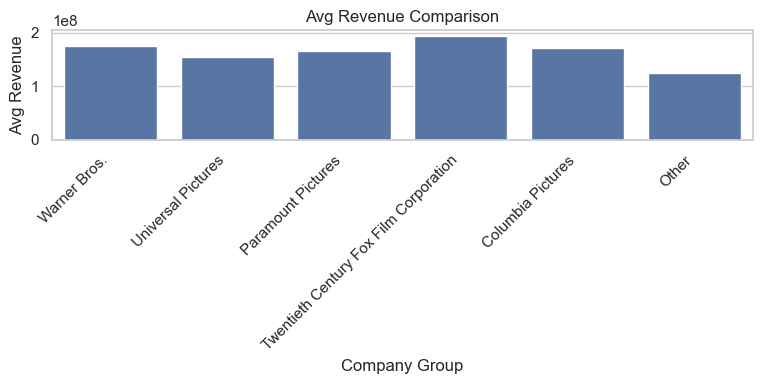

In [36]:
df['company_list'] = df['production_companies'] \
    .apply(ast.literal_eval) \
    .apply(lambda lst: [d['name'] for d in lst])
comp_exp = df.explode('company_list')

# Split: Top-5 production companies and 'Other'
top5 = comp_exp['company_list'].value_counts().nlargest(5).index.tolist()
comp_exp['company_group'] = comp_exp['company_list'].where(
    comp_exp['company_list'].isin(top5), 'Other'
)

#Apply: Group by company_group and calculate statistics
group_stats = comp_exp.groupby('company_group').agg(
    movie_count=('company_list','size'),
    avg_budget=('budget','mean'),
    avg_popularity=('popularity','mean'),
    avg_rating=('vote_average','mean'),
    avg_revenue=('revenue','mean')
).reindex(top5 + ['Other'])


print(group_stats)

# Combine: Plotting the statistics
for metric in ['avg_budget','avg_popularity','avg_rating','avg_revenue']:
    plt.figure(figsize=(8,4))
    sns.barplot(x=group_stats.index, y=metric, data=group_stats.reset_index())
    plt.xticks(rotation=45, ha='right')
    plt.title(f"{metric.replace('_',' ').title()} Comparison")
    plt.xlabel("Company Group")
    plt.ylabel(metric.replace('_',' ').title())
    plt.tight_layout()
    plt.show()

**Interpretation:** Because in previous analysis, we discover that budget, popularity and rating have strong correlation with revenue. As we all know, production companies have siginificant effect in these three features. So i want to find out their relationship. 

**Result:** 
- top companies have higher average budget than other companies.
- tom companies have higher average revenue than others, this may reflect the gap in commercial returns brought about by brand premium and channel advantages.
- top companies average rating are also higher than others which means that they are also better at attracting audience attention and gaining reputation. However, few other companies have a higher popularity and rating indicates the existence of niche masterpieces with certain quality and topic potential

## Overview

**From our previous Exploratory Data analysis, we can easily find out several key conclusion.**

1. Budget and revenue has a strong positive correlation. And correlation coefficients are often between 0.8 and 0.9.we can also include budget as our primary predictor variable in Regression analysis.

2. Popularity and revenue has moderate correlation while average rating has weak correlation with revenue.

3. There are highly skewed numerical distributions in variable like budget, revenue, popularity and vote_count. They have many extreme outliers or zeros.

4.	Categorical features like genre, original language and release year all Offer strong discrimination. This may be helpful in regression and classification analysis to help our model learn “genre → (high) revenue” relationships. Release year also can help analyze the market trend shifts over time. 

5. Revenue, budget, popularity and rating also can be affected by production companies.






# Step 5 : Clustering
**Purpose:** Cluster movies based on budget, revenue, and rating.

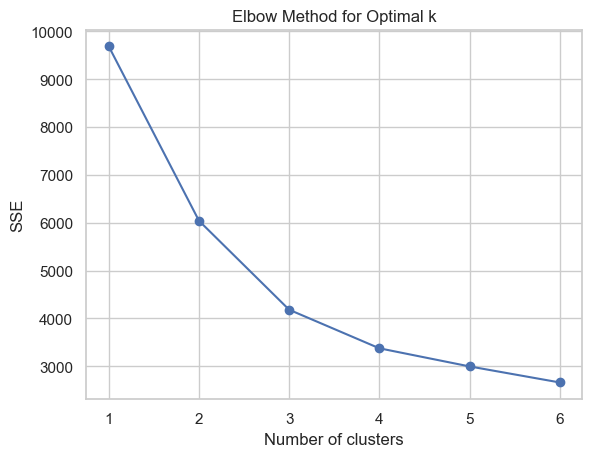

In [37]:
features = df[['budget','revenue','vote_average']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

sse = []
for k in range(1, 7):
    km = KMeans(n_clusters=k, random_state=0)
    km.fit(X_scaled)
    sse.append(km.inertia_)
plt.plot(range(1,7), sse, 'o-')
plt.xlabel('Number of clusters')
plt.ylabel('SSE')
plt.title('Elbow Method for Optimal k')
plt.show()



From the elbow plot, k=3 is selected as the optimal number of clusters.

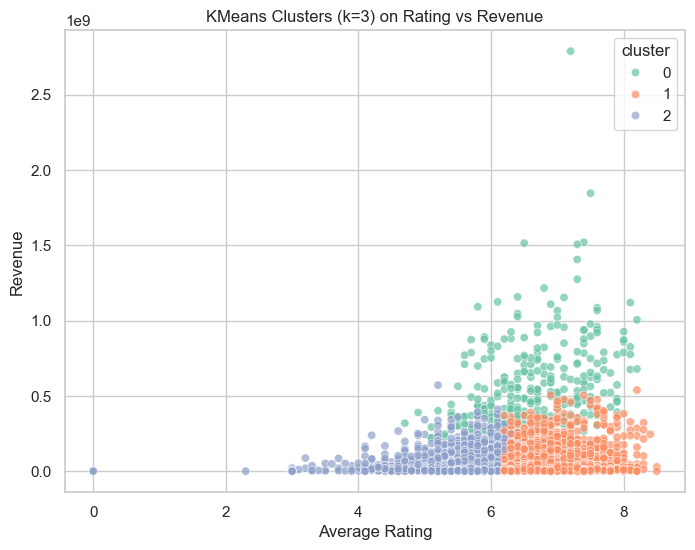

,budget,revenue,vote_average
0,1.399226e+08,5.397331e+08,6.596262
1,2.312589e+07,7.765130e+07,6.922760
2,3.720692e+07,7.207224e+07,5.540383


In [38]:
k_opt = 3 # Optimal number of clusters from elbow method
kmeans = KMeans(n_clusters=k_opt, random_state=0)
df['cluster'] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(
    x='vote_average', y='revenue',
    hue='cluster', palette='Set2',
    data=df, alpha=0.7
)
plt.title('KMeans Clusters (k=3) on Rating vs Revenue')
plt.xlabel('Average Rating')
plt.ylabel('Revenue')
plt.show()

centers = scaler.inverse_transform(kmeans.cluster_centers_)
cluster_summary = pd.DataFrame(
    centers,
    columns=['budget','revenue','vote_average']
)
display(cluster_summary)


**Interpretation：** Looking at the KMeans scatter plot (k = 3) on Average Rating (x-axis) vs. Revenue (y-axis):

**Cluster 0 (blue):** Low-Tier 
rating is mostly between ~3.5–6.0, revenue is concentrated near $0–$100 M. Which means these are smaller films with modest audience scores and low revenue returns.

**Cluster 1 (Orange):** Mid-Tier
raitng is between ~5.5-8.0 and revenue ranging from $50M to $300 M. films with medium budget can achieve solid commercial achievements.

**Cluster 2 (Green):** High-Tier
High budget and well rated movie can achieve high revenue. 



In this process, we can find that for low-tier films, they need more advertisement and popularity. For mid-tier flims, they need to banlance budget and movie quality in their market strategy. For High-tier films, it is necessary to increase promotion and ensure the film's critical reputation on the basis of a high budget to guarantee the top revenue.


# Step 6 : Regression Analysis
**Purpose:** Quantify how budget, popularity, and average rating linearly predict revenue.  

In [39]:
X = df[['budget', 'popularity', 'vote_average']]
y = df['revenue']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

# Training regression model
lr = LinearRegression()
lr.fit(X_train, y_train)
intercept = lr.intercept_
coeffs = pd.Series(lr.coef_, index=X.columns)
r2 = lr.score(X_test, y_test)

print(f"Intercept: {intercept:,.0f}")
print("Coefficients:")
print(coeffs.apply(lambda v: f"{v:,.2f}"))
print(f"R² on test set: {r2:.3f}")

Intercept: -185,941,374
Coefficients:
budget                   2.54
popularity       1,532,485.18
vote_average    25,466,257.66
dtype: object
R² on test set: 0.581


**Interpretation:** 

1. The budget coefficient is 2.54. This mean every extra $1 in budget predicts an extra $2.54 in revenue. This shows that higher production spending tends to roughly double or triple itself in return.

2. Public interest also has powerful affact. A one‐unit increase in the popularity score corresponds to about $1.53 million more revenue.

3. Although ratings aren’t as directly correlated as budget, a better‐rated movie still commands a large revenue premium.

4. Because R² ≈ 0.581, the model can explains about 58 % of the variance in revenue on unseen data. It’s a moderately strong fit, but it also tells us ~42 % of the variation is driven by other factors (genres, release timing, marketing, etc.) we haven’t included yet.
**Result:** 

# Step 7 : Classification with Decision Tree
**Purpose:** Predict whether a movie is 'high revenue'.

Because we care about "which movies make the big revenue".we can answer this question by building a high/low revenue binary classification model.Classification can tells us that "the more you exceed the budget, the more likely we are to be at the revenue".

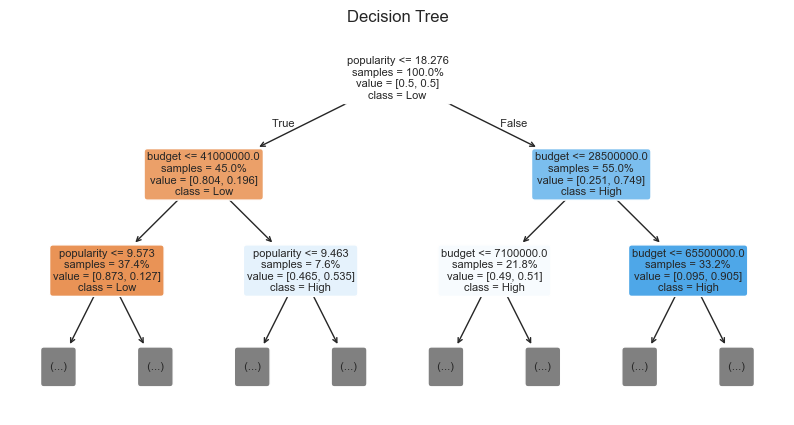

Accuracy: 0.79

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.81      0.80       485
           1       0.80      0.77      0.79       484

    accuracy                           0.79       969
   macro avg       0.79      0.79      0.79       969
weighted avg       0.79      0.79      0.79       969



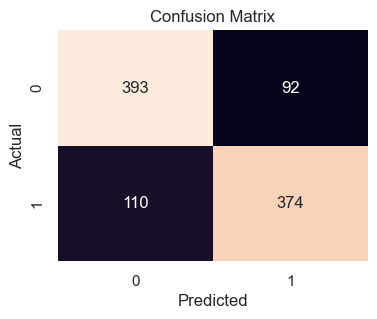

Feature Importances:
 popularity      0.671280
budget          0.300969
vote_average    0.027751
dtype: float64


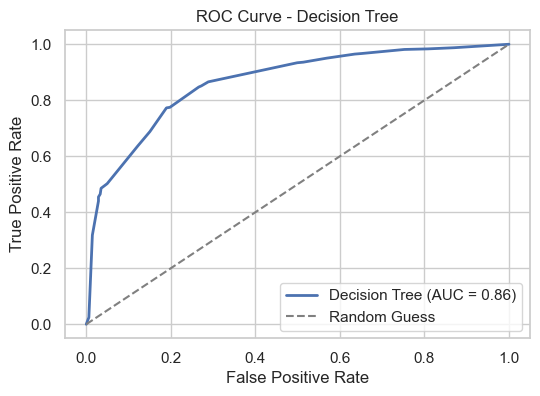

In [40]:
df['high_revenue'] = (df['revenue'] > df['revenue'].median()).astype(int)
X = df[['budget','popularity','vote_average']]
y = df['high_revenue']

# Split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0, stratify=y
)

#Decision Tree
clf = DecisionTreeClassifier(
    max_depth=5,
    class_weight='balanced',
    random_state=0
)
clf.fit(X_train, y_train)
plt.figure(figsize=(10, 5))
plot_tree(
    clf,
    feature_names=X.columns,
    class_names=['Low', 'High'],
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=2,      
    impurity=False,   
    proportion=True   
)
plt.title("Decision Tree")
plt.show()

#Predict and evaluate
y_pred = clf.predict(X_test)
print("Accuracy:", f"{accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#Feature importances
feat_imp = pd.Series(clf.feature_importances_, index=X.columns)
print("Feature Importances:\n", feat_imp.sort_values(ascending=False))

#ROC
y_proba_dt = clf.predict_proba(X_test)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

plt.figure(figsize=(6, 4))
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {roc_auc_dt:.2f})', linestyle='-', linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Decision Tree')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


*Note: Tree truncated at depth=2 for clarity; deeper splits omitted.*

**Interpretation:** 

**1.Overall Accuracy ≈ 0.79 indicating a strong baseline performance.**

**2.Confusion Matrix**
      Note: 0=Low 1=High 

   ```text
                Predicted
              Low     High
   Actual Low  TN      FP
          High FN      TP
    
    True Negatives and True Positives dominate showing balanced performance. False Positives and False Negatives are roughly equal, so there’s no strong bias toward one class.



**3. Precision / Recall / F1**
Low-Revenue Class: Precision ≈ 0.78, Recall ≈ 0.81 → the model is slightly better at identifying true low-revenue films than avoiding false alarms.
High-Revenue Class: Precision ≈ 0.80, Recall ≈ 0.77 → it predicts high-revenue films with high confidence, though it misses about 23% of them.

**4. Feature Importance**
1. budget         (highest importance)  
2. popularity     (moderate importance)  
3. vote_average   (lower, but still meaningful)

Budget is the strongest predictor, followed by public interest and then average rating.

**5. ROC curve:** the curve is close to the top left corner. It indicates that the model has the ability to distinguish between high revenue and low revenue. AUC = 0.86

## Comparison
**Why choose decision tree model?**
To better understand the performance of the model, let's introduce a comparison model: Logistic Regression. Logistic regression is a linear classification model that can be used as a benchmark model.

Logistic Regression Accuracy: 0.52

Classification Report (LR):
               precision    recall  f1-score   support

           0       1.00      0.05      0.09       485
           1       0.51      1.00      0.68       484

    accuracy                           0.52       969
   macro avg       0.76      0.52      0.38       969
weighted avg       0.76      0.52      0.38       969



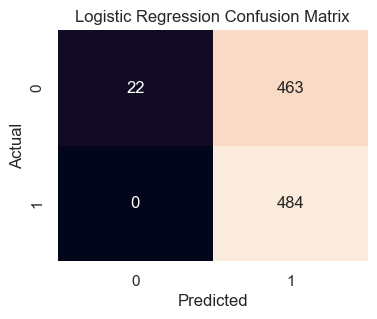

In [41]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=0)
lr.fit(X_train, y_train)

# Predict and evaluate
y_pred_lr = lr.predict(X_test)
print("Logistic Regression Accuracy:", f"{accuracy_score(y_test, y_pred_lr):.2f}")
print("\nClassification Report (LR):\n", classification_report(y_test, y_pred_lr))

# Confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(4, 3))
sns.heatmap(cm_lr, annot=True, fmt='d', cbar=False)
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Result:** 
- The accuracy of the model is only 0.52, and the performance is close to random guessing;
- The model predicts high revenue (category 1) for almost all test samples with a recall of 1.00;
- But for low-income films (category 0), the identification almost completely failed (Recall = 0.05).

Therefore, we choose to retain the decision tree model as the main analysis tool, while logistic regression is used as the comparison model to demonstrate the responses of different modeling methods to data characteristics


# Step 8 : Summary and Limitation

## Summary

- **EDA (Exploratory Data Analysis)**  
  - Identified right-skewed distributions for budget, revenue, popularity, and ratings; observed significant differences in revenue and ratings across budget buckets, genres, and release years.  
  - Used histograms, boxplots, heatmaps, and time-series plots to reveal distribution patterns and inter-variable relationships.

- **Clustering Analysis**  
  - Discovered three natural commercial tiers—“Low-Tier,” “Mid-Tier,” and “High-Tier”—with cluster centers quantifying average budget, revenue, and rating for each.  
  - This segmentation validated the stratifying effect of budget on revenue and provided an optional cluster-label feature for subsequent models.

- **Regression Analysis**  
  - Achieved R² ≈ 0.58 on the test set, showing that budget, popularity, and rating explain about 58% of revenue variance.  
  - Quantified effects: each additional \$1 of budget predicts ~\$2.54 more revenue; each unit increase in popularity adds ~\$1.53M; each one-point rise in rating adds ~\$25.5M.

- **Classification Analysis**  
  - Binary classification accuracy ≈ 79%, with balanced precision and recall across low- and high-revenue classes.  
  - Key decision rules: first split on popularity (≤18.3), then on budget thresholds (~\$28–\$41M); feature importances rank as budget > popularity > rating.


## Limitation

- In my analysis, i only use budget, popularity，rating and production company these numerical and categorical features. Other improtant data, like genres and releasse years and overviews, tagline aren't included. This leads to model insufficiently capture multi-dimensional factors.
- Linear regression R² ≈ 0.58 indicates that approximately 42% of revenue fluctuations remain unexplained.
- overall accuracy ≈ 0.79 reflecting the limited learning ability of the model for complex nonlinear relationships and a few extreme samples.
- The lack of external environment factors like release year, social trends and publish channel.

## Future Work

- **Feature Expansion:** Add genre, language, release date dummies, and text‐based sentiment features  
- **Algorithm Upgrade:** Experiment with Random Forest, XGBoost, and regularized regression; use cross‐validation for tuning  
- **External Validation & Deployment:** Validate on IMDb/Box Office Mojo data; build an automated prediction pipeline  